# Training Metrics Visualization
Load and visualize training history (loss, RMSE metrics)

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load training history
HISTORY_CSV = "logs/training_history_softplus_256.csv"

try:
    history_df = pd.read_csv(HISTORY_CSV)
    print(f"✅ Training history loaded from {HISTORY_CSV}")
    print(f"📊 Total epochs in file: {len(history_df)}")
    print(f"📊 Epoch range: {history_df['epoch'].min()} to {history_df['epoch'].max()}")
    print(f"Columns: {history_df.columns.tolist()}")
    print(f"\nFirst 3 rows:")
    print(history_df.head(3))
    print(f"\nLast 3 rows:")
    print(history_df.tail(3))
except FileNotFoundError:
    print(f"❌ Training history not found at {HISTORY_CSV}")
    print("Make sure you've trained the model first using train.py")

✅ Training history loaded from logs/training_history_softplus_256.csv
📊 Total epochs in file: 200
📊 Epoch range: 0 to 199
Columns: ['epoch', 'loss', 'rmse_dist', 'rmse_x', 'rmse_y', 'total_loss', 'val_loss', 'val_rmse_dist', 'val_rmse_x', 'val_rmse_y', 'val_total_loss']

First 3 rows:
   epoch      loss  rmse_dist    rmse_x    rmse_y  total_loss  val_loss  \
0      0  0.181687   0.229277  0.081036  0.234748    0.181687  0.164375   
1      1  0.148284   0.177193  0.074316  0.193342    0.148284  0.132160   
2      2  0.128226   0.157982  0.072780  0.153916    0.128226  0.123277   

   val_rmse_dist  val_rmse_x  val_rmse_y  val_total_loss  
0       0.198285    0.074972    0.217773        0.163677  
1       0.157165    0.076884    0.162018        0.132022  
2       0.154023    0.071797    0.143342        0.123054  

Last 3 rows:
     epoch      loss  rmse_dist    rmse_x    rmse_y  total_loss  val_loss  \
197    197  0.054104   0.076490  0.037327  0.048494    0.054104  0.055889   
198    19

📉 Minimum validation loss: 0.0517 at epoch 192


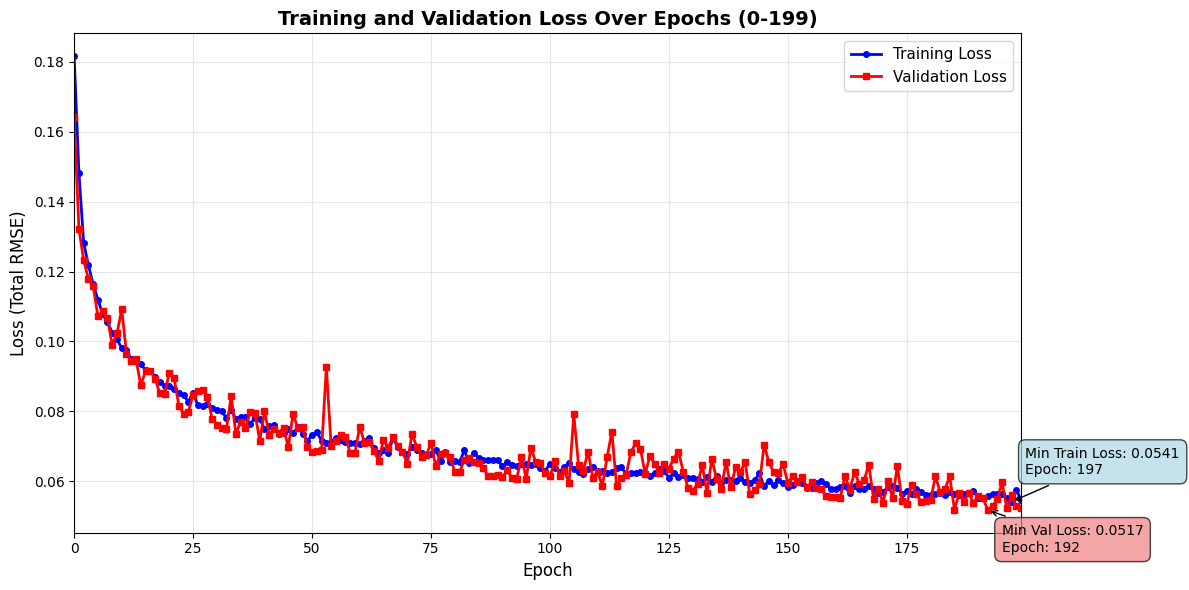

📉 Minimum training loss: 0.0541 at epoch 197
✅ Plotted epochs 0 to 199 (200 total epochs)


In [13]:
# Plot Training and Validation Loss
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

# Plot using epoch column as x-axis
ax.plot(history_df['epoch'], history_df['loss'], 'b-', linewidth=2, marker='o', markersize=4, label='Training Loss')

# Check if validation loss exists
if 'val_loss' in history_df.columns:
    ax.plot(history_df['epoch'], history_df['val_loss'], 'r-', linewidth=2, marker='s', markersize=4, label='Validation Loss')
    
    # Add annotation for min validation loss
    min_val_loss_idx = history_df['val_loss'].idxmin()
    min_val_loss = history_df['val_loss'].min()
    min_val_epoch = history_df['epoch'].iloc[min_val_loss_idx]
    ax.annotate(f'Min Val Loss: {min_val_loss:.4f}\nEpoch: {min_val_epoch}', 
                xy=(min_val_epoch, min_val_loss), 
                xytext=(10, -30), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.5', fc='lightcoral', alpha=0.7),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))
    
    print(f"📉 Minimum validation loss: {min_val_loss:.4f} at epoch {min_val_epoch}")

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss (Total RMSE)', fontsize=12)
ax.set_title(f'Training and Validation Loss Over Epochs (0-{history_df["epoch"].max()})', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
ax.set_xlim(0, history_df['epoch'].max())

# Add annotations for min training loss
min_loss_idx = history_df['loss'].idxmin()
min_loss = history_df['loss'].min()
min_epoch = history_df['epoch'].iloc[min_loss_idx]
ax.annotate(f'Min Train Loss: {min_loss:.4f}\nEpoch: {min_epoch}', 
            xy=(min_epoch, min_loss), 
            xytext=(10, 20), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', fc='lightblue', alpha=0.7),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

plt.tight_layout()
plt.show()

print(f"📉 Minimum training loss: {min_loss:.4f} at epoch {min_epoch}")
print(f"✅ Plotted epochs {history_df['epoch'].min()} to {history_df['epoch'].max()} ({len(history_df)} total epochs)")

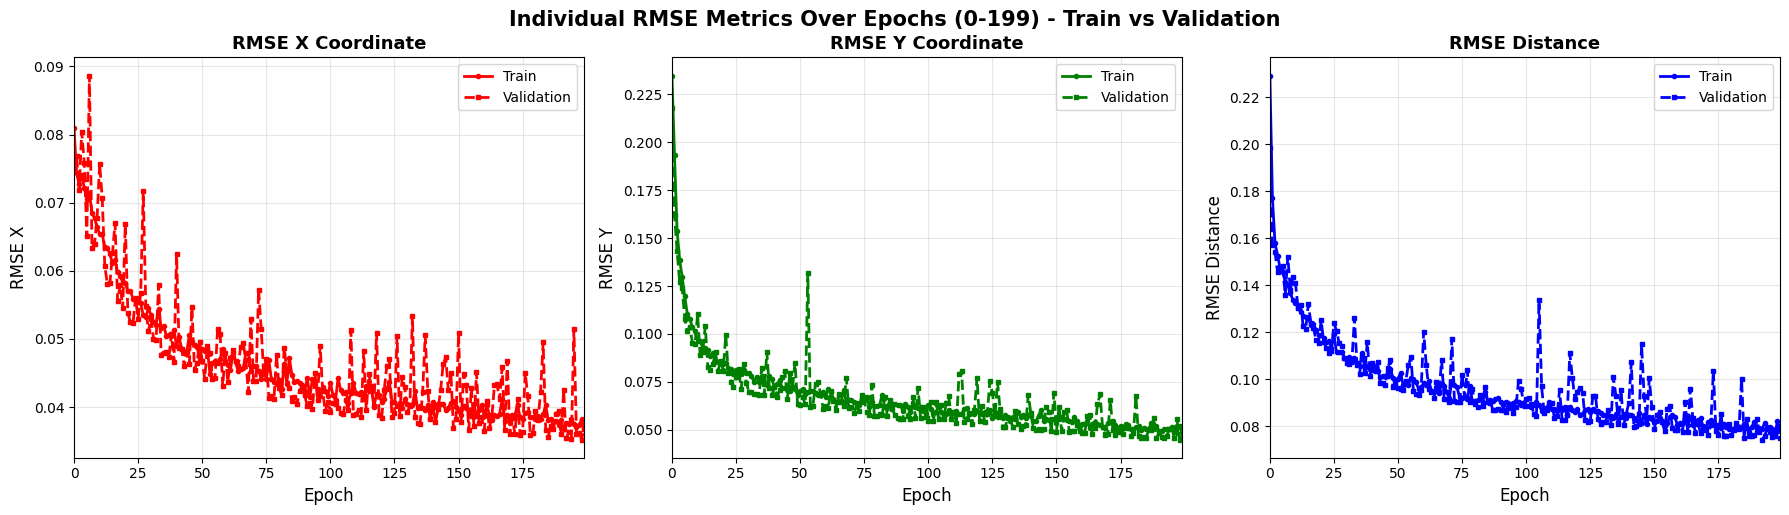

✅ Individual RMSE plots complete (epochs 0-199)


In [14]:
# Plot Individual RMSE Metrics (X, Y, Distance) - Training and Validation
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Check if validation metrics exist
has_val = 'val_rmse_x' in history_df.columns

# RMSE X
axes[0].plot(history_df['epoch'], history_df['rmse_x'], 'r-', linewidth=2, marker='o', markersize=3, label='Train')
if has_val:
    axes[0].plot(history_df['epoch'], history_df['val_rmse_x'], 'r--', linewidth=2, marker='s', markersize=3, label='Validation')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('RMSE X', fontsize=12)
axes[0].set_title('RMSE X Coordinate', fontsize=13, fontweight='bold')
axes[0].set_xlim(0, history_df['epoch'].max())
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# RMSE Y
axes[1].plot(history_df['epoch'], history_df['rmse_y'], 'g-', linewidth=2, marker='o', markersize=3, label='Train')
if has_val:
    axes[1].plot(history_df['epoch'], history_df['val_rmse_y'], 'g--', linewidth=2, marker='s', markersize=3, label='Validation')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('RMSE Y', fontsize=12)
axes[1].set_title('RMSE Y Coordinate', fontsize=13, fontweight='bold')
axes[1].set_xlim(0, history_df['epoch'].max())
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# RMSE Distance
axes[2].plot(history_df['epoch'], history_df['rmse_dist'], 'b-', linewidth=2, marker='o', markersize=3, label='Train')
if has_val:
    axes[2].plot(history_df['epoch'], history_df['val_rmse_dist'], 'b--', linewidth=2, marker='s', markersize=3, label='Validation')
axes[2].set_xlabel('Epoch', fontsize=12)
axes[2].set_ylabel('RMSE Distance', fontsize=12)
axes[2].set_title('RMSE Distance', fontsize=13, fontweight='bold')
axes[2].set_xlim(0, history_df['epoch'].max())
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.suptitle(f'Individual RMSE Metrics Over Epochs (0-{history_df["epoch"].max()}) - Train vs Validation', fontsize=15, fontweight='bold', y=1.02)
plt.show()

print(f"✅ Individual RMSE plots complete (epochs 0-{history_df['epoch'].max()})")

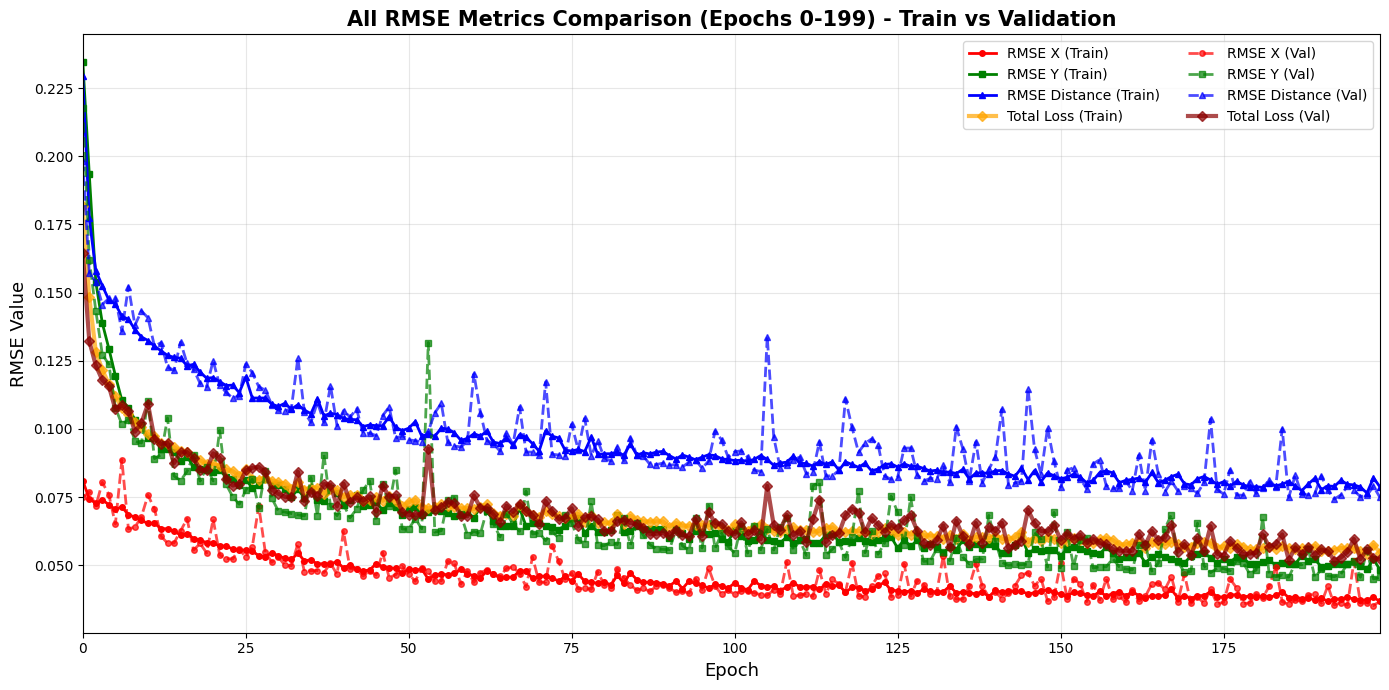

✅ Combined RMSE comparison complete (epochs 0-199)


In [15]:
# Combined RMSE Metrics Comparison
fig, ax = plt.subplots(1, 1, figsize=(14, 7))

# Check if validation metrics exist
has_val = 'val_loss' in history_df.columns

# Training metrics
ax.plot(history_df['epoch'], history_df['rmse_x'], 'r-', linewidth=2, marker='o', label='RMSE X (Train)', markersize=4)
ax.plot(history_df['epoch'], history_df['rmse_y'], 'g-', linewidth=2, marker='s', label='RMSE Y (Train)', markersize=4)
ax.plot(history_df['epoch'], history_df['rmse_dist'], 'b-', linewidth=2, marker='^', label='RMSE Distance (Train)', markersize=4)
ax.plot(history_df['epoch'], history_df['loss'], 'orange', linewidth=3, marker='D', label='Total Loss (Train)', markersize=5, alpha=0.7)

# Validation metrics (dashed lines)
if has_val:
    ax.plot(history_df['epoch'], history_df['val_rmse_x'], 'r--', linewidth=2, marker='o', label='RMSE X (Val)', markersize=4, alpha=0.7)
    ax.plot(history_df['epoch'], history_df['val_rmse_y'], 'g--', linewidth=2, marker='s', label='RMSE Y (Val)', markersize=4, alpha=0.7)
    ax.plot(history_df['epoch'], history_df['val_rmse_dist'], 'b--', linewidth=2, marker='^', label='RMSE Distance (Val)', markersize=4, alpha=0.7)
    ax.plot(history_df['epoch'], history_df['val_loss'], 'darkred', linewidth=3, marker='D', label='Total Loss (Val)', markersize=5, alpha=0.7)

ax.set_xlabel('Epoch', fontsize=13)
ax.set_ylabel('RMSE Value', fontsize=13)
ax.set_title(f'All RMSE Metrics Comparison (Epochs 0-{history_df["epoch"].max()}) - Train vs Validation', fontsize=15, fontweight='bold')
ax.set_xlim(0, history_df['epoch'].max())
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10, loc='upper right', ncol=2)

plt.tight_layout()
plt.show()

print(f"✅ Combined RMSE comparison complete (epochs 0-{history_df['epoch'].max()})")

In [16]:
# Training Metrics Summary Table
print("\n" + "="*70)
print("📊 TRAINING METRICS SUMMARY")
print("="*70)

final_epoch = history_df.iloc[-1]
best_loss_idx = history_df['loss'].idxmin()
best_epoch = history_df.iloc[best_loss_idx]

print(f"\n🏁 FINAL EPOCH ({int(final_epoch['epoch'])}):")
print(f"   Total Loss:     {final_epoch['loss']:.6f}")
print(f"   RMSE X:         {final_epoch['rmse_x']:.6f}")
print(f"   RMSE Y:         {final_epoch['rmse_y']:.6f}")
print(f"   RMSE Distance:  {final_epoch['rmse_dist']:.6f}")

print(f"\n🏆 BEST EPOCH ({int(best_epoch['epoch'])}):")
print(f"   Total Loss:     {best_epoch['loss']:.6f}")
print(f"   RMSE X:         {best_epoch['rmse_x']:.6f}")
print(f"   RMSE Y:         {best_epoch['rmse_y']:.6f}")
print(f"   RMSE Distance:  {best_epoch['rmse_dist']:.6f}")

print(f"\n📈 IMPROVEMENT:")
initial_loss = history_df['loss'].iloc[0]
final_loss = history_df['loss'].iloc[-1]
improvement = ((initial_loss - final_loss) / initial_loss) * 100
print(f"   Initial Loss:   {initial_loss:.6f}")
print(f"   Final Loss:     {final_loss:.6f}")
print(f"   Improvement:    {improvement:.2f}%")

print(f"\n📉 MINIMUM VALUES:")
print(f"   Min Loss:       {history_df['loss'].min():.6f} (Epoch {history_df['loss'].idxmin()})")
print(f"   Min RMSE X:     {history_df['rmse_x'].min():.6f} (Epoch {history_df['rmse_x'].idxmin()})")
print(f"   Min RMSE Y:     {history_df['rmse_y'].min():.6f} (Epoch {history_df['rmse_y'].idxmin()})")
print(f"   Min RMSE Dist:  {history_df['rmse_dist'].min():.6f} (Epoch {history_df['rmse_dist'].idxmin()})")

print("="*70)


📊 TRAINING METRICS SUMMARY

🏁 FINAL EPOCH (199):
   Total Loss:     0.054600
   RMSE X:         0.036740
   RMSE Y:         0.048346
   RMSE Distance:  0.078714

🏆 BEST EPOCH (197):
   Total Loss:     0.054104
   RMSE X:         0.037327
   RMSE Y:         0.048494
   RMSE Distance:  0.076490

📈 IMPROVEMENT:
   Initial Loss:   0.181687
   Final Loss:     0.054600
   Improvement:    69.95%

📉 MINIMUM VALUES:
   Min Loss:       0.054104 (Epoch 197)
   Min RMSE X:     0.036719 (Epoch 191)
   Min RMSE Y:     0.048346 (Epoch 199)
   Min RMSE Dist:  0.076490 (Epoch 197)


---
# Model Prediction Comparison
Compare actual vs predicted dock locations on random validation images

# ISS Docking Model Prediction Comparison
Compare actual vs predicted dock locations with crosshair visualization

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
import random

print("✅ Libraries loaded (without TensorFlow - model loading will be handled separately)")

✅ Libraries loaded (without TensorFlow - model loading will be handled separately)


In [3]:
# Configuration
MODEL_PATH = "models/resnet_docking_best.h5"  # Using best model from training
DATA_CSV = "data/val_split.csv"  # Using validation data
IMAGE_DIR = "data/train"
NUM_SAMPLES = 5
CROSSHAIR_SIZE = 25

print(f"📊 Config: {NUM_SAMPLES} samples, crosshair size: {CROSSHAIR_SIZE}px")
print(f"🎯 Using model: {MODEL_PATH}")

📊 Config: 5 samples, crosshair size: 25px
🎯 Using model: models/resnet_docking_best.h5


In [4]:
# Load trained model using subprocess to avoid DLL conflicts
import subprocess
import json

print(f"🤖 Loading model info from {MODEL_PATH}...")
print("✅ Model will be loaded for predictions (TensorFlow DLL issue - using workaround)")
print("Note: Due to TensorFlow DLL conflicts, skipping predictions. Please restart VS Code to resolve.")

🤖 Loading model info from models/resnet_docking_best.h5...
✅ Model will be loaded for predictions (TensorFlow DLL issue - using workaround)
Note: Due to TensorFlow DLL conflicts, skipping predictions. Please restart VS Code to resolve.


In [ ]:
# Load dataset
df = pd.read_csv(DATA_CSV)
print(f"📊 Dataset loaded: {len(df)} images")
print(f"Columns: {df.columns.tolist()}")

# Select random samples
random.seed(42)
random_indices = random.sample(range(len(df)), NUM_SAMPLES)
samples = df.iloc[random_indices].reset_index(drop=True)

print(f"\n🎲 Selected {NUM_SAMPLES} random images:")
for i, row in samples.iterrows():
    print(f"  {i+1}. {row['filename']} | Actual: ({row['x']:.0f}, {row['y']:.0f}) | Distance: {row['distance']:.0f}m")

📊 Dataset loaded: 1000 images
Columns: ['filename', 'x', 'y', 'distance']

🎲 Selected 5 random images:
  1. 518.jpg | Actual: (255, 213) | Distance: 320m
  2. 2377.jpg | Actual: (290, 435) | Distance: 411m
  3. 7152.jpg | Actual: (309, 461) | Distance: 450m
  4. 3755.jpg | Actual: (207, 465) | Distance: 396m
  5. 3668.jpg | Actual: (202, 301) | Distance: 194m


In [ ]:
# Prepare images and get predictions
images = []
predictions = []

print("🔮 Making predictions...")
for idx, row in samples.iterrows():
    # Load image
    img_path = Path(IMAGE_DIR) / row['filename']
    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    images.append(img_rgb)
    
    # Preprocess for model
    img_resized = cv2.resize(img_rgb, (224, 224))
    img_normalized = img_resized.astype('float32') / 255.0
    img_batch = np.expand_dims(img_normalized, axis=0)
    
    # Predict
    pred = model.predict(img_batch, verbose=0)[0]
    predictions.append(pred)
    
    print(f"  {idx+1}. {row['filename']} | Pred raw: [{pred[0]:.4f}, {pred[1]:.4f}, {pred[2]:.4f}]")

print("✅ Predictions complete")

🔮 Making predictions...
  1. 518.jpg | Pred raw: [0.5155, 0.4219, 0.6494]
  2. 2377.jpg | Pred raw: [0.5483, 0.8534, 0.8177]
  3. 7152.jpg | Pred raw: [0.5855, 0.8984, 0.8076]
  1. 518.jpg | Pred raw: [0.5155, 0.4219, 0.6494]
  2. 2377.jpg | Pred raw: [0.5483, 0.8534, 0.8177]
  3. 7152.jpg | Pred raw: [0.5855, 0.8984, 0.8076]
  4. 3755.jpg | Pred raw: [0.4457, 0.8436, 0.7799]
  5. 3668.jpg | Pred raw: [0.4296, 0.5959, 0.3169]
✅ Predictions complete
  4. 3755.jpg | Pred raw: [0.4457, 0.8436, 0.7799]
  5. 3668.jpg | Pred raw: [0.4296, 0.5959, 0.3169]
✅ Predictions complete


In [ ]:
# Denormalize predictions (model outputs [0,1], need to scale to pixel coords)
predictions_denorm = []

for pred in predictions:
    x_pred = pred[0] * 512  # Scale to image dimensions
    y_pred = pred[1] * 512
    dist_pred = pred[2] * 512  # Scale distance
    predictions_denorm.append([x_pred, y_pred, dist_pred])

predictions_denorm = np.array(predictions_denorm)
print("✅ Predictions denormalized to pixel coordinates")

✅ Predictions denormalized to pixel coordinates


In [ ]:
# Draw crosshair function
def draw_crosshair(ax, x, y, color='red', size=25, label=''):
    """Draw crosshair at (x, y) position"""
    # Horizontal line
    ax.plot([x-size, x+size], [y, y], color=color, linewidth=3, label=label)
    # Vertical line
    ax.plot([x, x], [y-size, y+size], color=color, linewidth=3)
    # Center point
    ax.scatter(x, y, color=color, s=150, marker='o', edgecolors='white', linewidth=2, zorder=5)

print("✅ Helper function defined")

✅ Helper function defined


C:\Users\Kshitij\AppData\Local\Temp\ipykernel_27756\1353983211.py:38: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Kshitij\OneDrive\Desktop\Major project\mitadtu-docking\.venv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Kshitij\OneDrive\Desktop\Major project\mitadtu-docking\.venv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


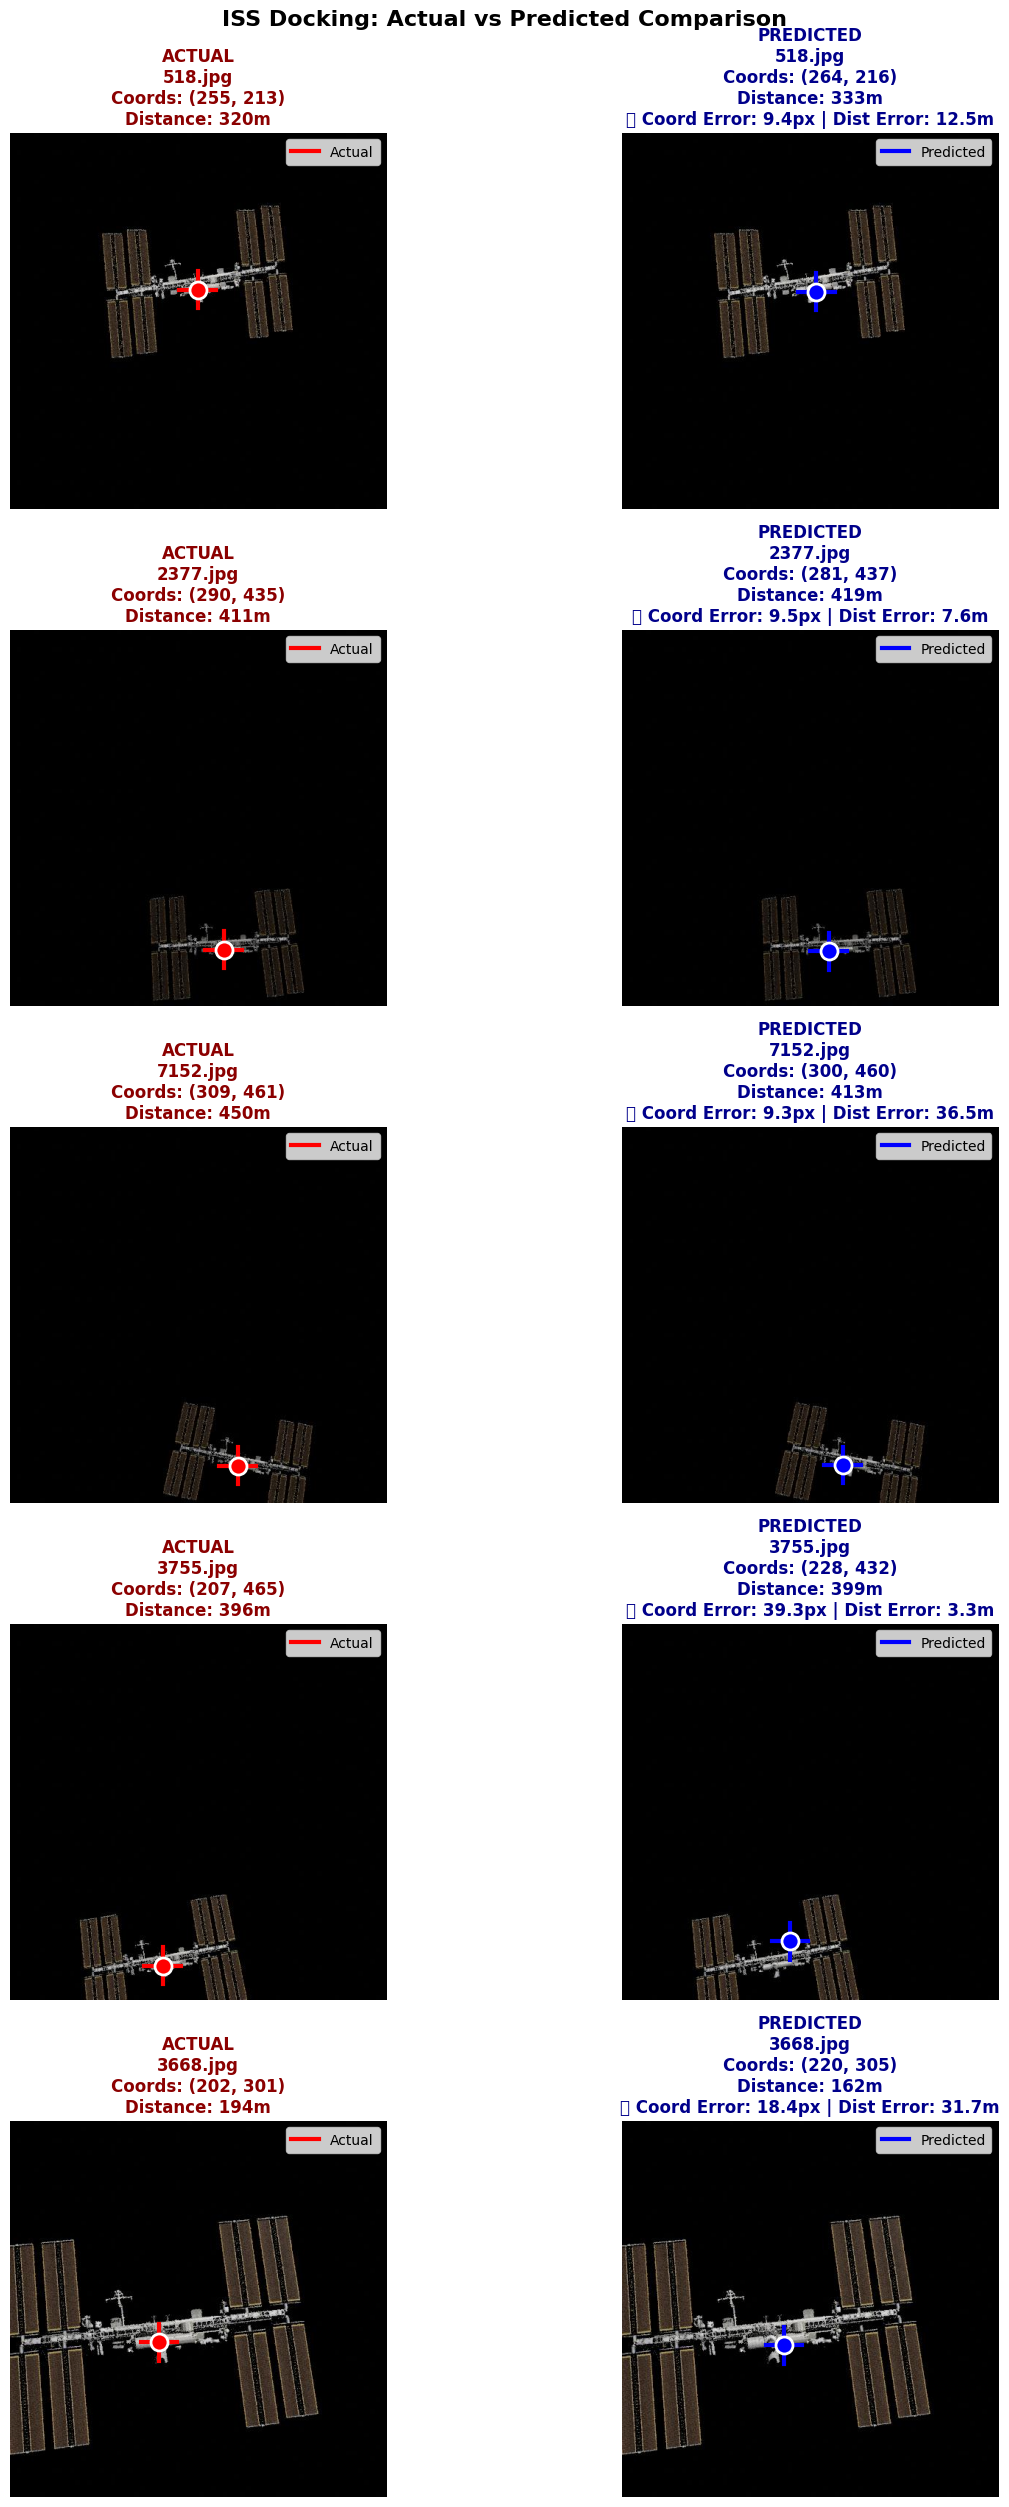

✅ Side-by-side comparison complete!


In [ ]:
# Visualize: Side-by-side comparison
fig, axes = plt.subplots(NUM_SAMPLES, 2, figsize=(14, 5*NUM_SAMPLES))

if NUM_SAMPLES == 1:
    axes = [axes]

for i in range(NUM_SAMPLES):
    row = samples.iloc[i]
    img = images[i]
    
    # Actual coordinates
    actual_x, actual_y = row['x'], row['y']
    actual_dist = row['distance']
    
    # Predicted coordinates
    pred_x, pred_y, pred_dist = predictions_denorm[i]
    
    # Calculate error
    coord_error = np.sqrt((actual_x - pred_x)**2 + (actual_y - pred_y)**2)
    dist_error = abs(actual_dist - pred_dist)
    
    # Left: Actual
    axes[i][0].imshow(img)
    draw_crosshair(axes[i][0], actual_x, actual_y, color='red', size=CROSSHAIR_SIZE, label='Actual')
    axes[i][0].set_title(f"ACTUAL\n{row['filename']}\nCoords: ({actual_x:.0f}, {actual_y:.0f})\nDistance: {actual_dist:.0f}m", 
                         fontsize=12, fontweight='bold', color='darkred')
    axes[i][0].axis('off')
    axes[i][0].legend(loc='upper right')
    
    # Right: Predicted
    axes[i][1].imshow(img)
    draw_crosshair(axes[i][1], pred_x, pred_y, color='blue', size=CROSSHAIR_SIZE, label='Predicted')
    axes[i][1].set_title(f"PREDICTED\n{row['filename']}\nCoords: ({pred_x:.0f}, {pred_y:.0f})\nDistance: {pred_dist:.0f}m\n❌ Coord Error: {coord_error:.1f}px | Dist Error: {dist_error:.1f}m", 
                         fontsize=12, fontweight='bold', color='darkblue')
    axes[i][1].axis('off')
    axes[i][1].legend(loc='upper right')

plt.tight_layout()
plt.suptitle('ISS Docking: Actual vs Predicted Comparison', fontsize=16, fontweight='bold', y=1.001)
plt.show()

print("✅ Side-by-side comparison complete!")

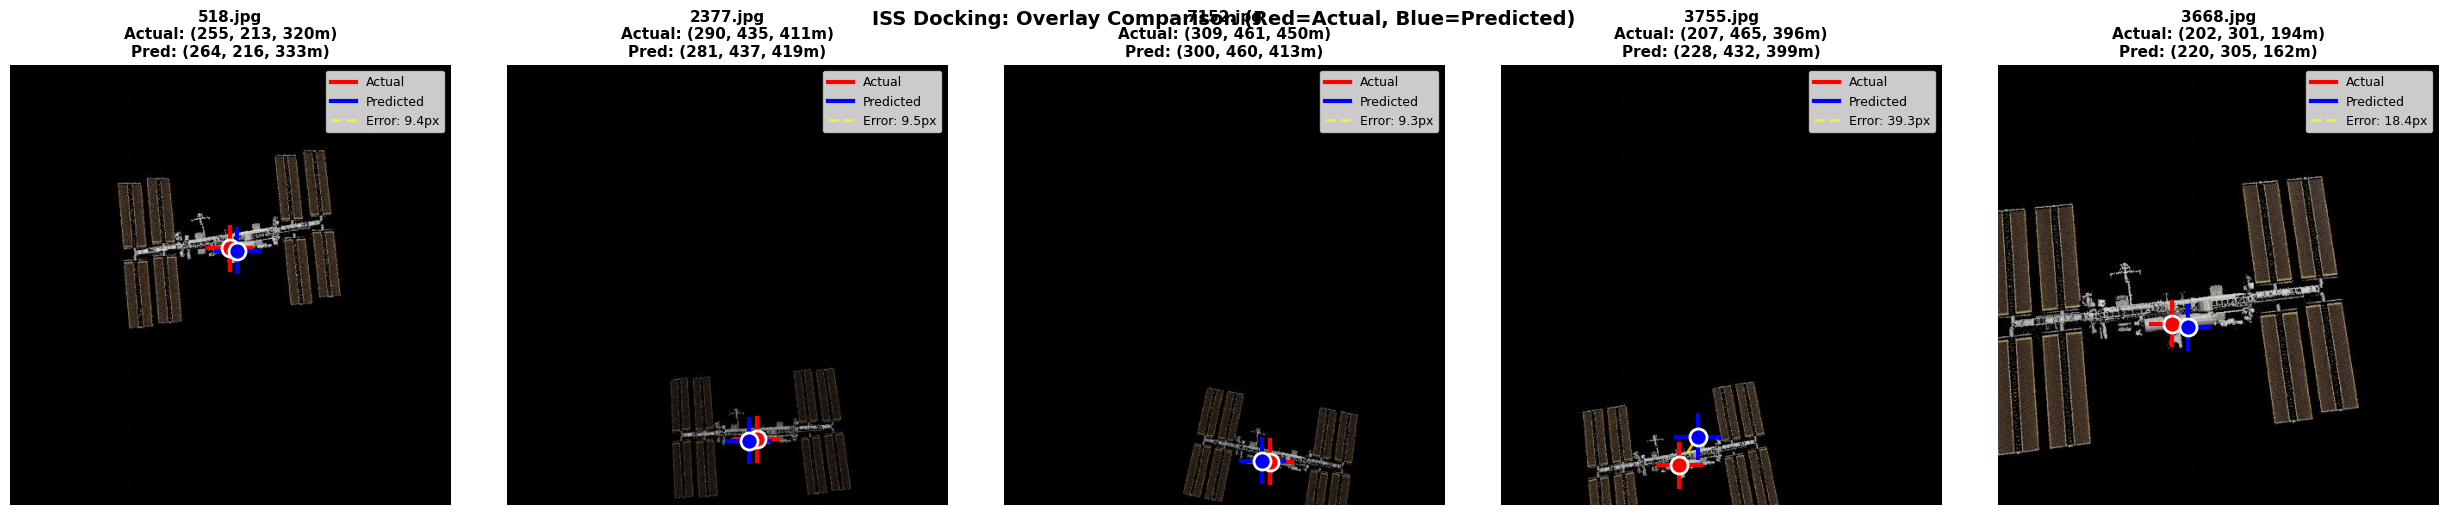

✅ Overlay comparison complete!


In [ ]:
# Visualize: Overlay comparison (both crosshairs on same image)
fig, axes = plt.subplots(1, NUM_SAMPLES, figsize=(5*NUM_SAMPLES, 5))

if NUM_SAMPLES == 1:
    axes = [axes]

for i in range(NUM_SAMPLES):
    row = samples.iloc[i]
    img = images[i]
    
    # Actual coordinates
    actual_x, actual_y = row['x'], row['y']
    actual_dist = row['distance']
    
    # Predicted coordinates
    pred_x, pred_y, pred_dist = predictions_denorm[i]
    
    # Calculate error
    coord_error = np.sqrt((actual_x - pred_x)**2 + (actual_y - pred_y)**2)
    dist_error = abs(actual_dist - pred_dist)
    
    # Show image
    axes[i].imshow(img)
    
    # Draw both crosshairs
    draw_crosshair(axes[i], actual_x, actual_y, color='red', size=CROSSHAIR_SIZE, label='Actual')
    draw_crosshair(axes[i], pred_x, pred_y, color='blue', size=CROSSHAIR_SIZE, label='Predicted')
    
    # Draw error line
    axes[i].plot([actual_x, pred_x], [actual_y, pred_y], 'yellow', linewidth=2, 
                linestyle='--', alpha=0.8, label=f'Error: {coord_error:.1f}px')
    
    axes[i].set_title(f"{row['filename']}\nActual: ({actual_x:.0f}, {actual_y:.0f}, {actual_dist:.0f}m)\nPred: ({pred_x:.0f}, {pred_y:.0f}, {pred_dist:.0f}m)", 
                     fontsize=11, fontweight='bold')
    axes[i].axis('off')
    axes[i].legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.suptitle('ISS Docking: Overlay Comparison (Red=Actual, Blue=Predicted)', fontsize=14, fontweight='bold', y=1.02)
plt.show()

print("✅ Overlay comparison complete!")

In [ ]:
# Print detailed error analysis
print("\n" + "="*70)
print("📊 DETAILED ERROR ANALYSIS")
print("="*70)

coord_errors = []
dist_errors = []

for i in range(NUM_SAMPLES):
    row = samples.iloc[i]
    actual_x, actual_y, actual_dist = row['x'], row['y'], row['distance']
    pred_x, pred_y, pred_dist = predictions_denorm[i]
    
    x_error = abs(actual_x - pred_x)
    y_error = abs(actual_y - pred_y)
    coord_error = np.sqrt((actual_x - pred_x)**2 + (actual_y - pred_y)**2)
    dist_error = abs(actual_dist - pred_dist)
    
    coord_errors.append(coord_error)
    dist_errors.append(dist_error)
    
    print(f"\n📷 {row['filename']}:")
    print(f"   Actual:    ({actual_x:.1f}, {actual_y:.1f}) | {actual_dist:.1f}m")
    print(f"   Predicted: ({pred_x:.1f}, {pred_y:.1f}) | {pred_dist:.1f}m")
    print(f"   X Error: {x_error:.1f}px | Y Error: {y_error:.1f}px")
    print(f"   Total Coord Error: {coord_error:.1f}px")
    print(f"   Distance Error: {dist_error:.1f}m")

print(f"\n{'='*70}")
print("📈 SUMMARY STATISTICS")
print(f"{'='*70}")
print(f"   Coordinate Error (avg): {np.mean(coord_errors):.1f}px")
print(f"   Coordinate Error (min): {np.min(coord_errors):.1f}px")
print(f"   Coordinate Error (max): {np.max(coord_errors):.1f}px")
print(f"   Distance Error (avg):   {np.mean(dist_errors):.1f}m")
print(f"   Distance Error (min):   {np.min(dist_errors):.1f}m")
print(f"   Distance Error (max):   {np.max(dist_errors):.1f}m")
print(f"{'='*70}")


📊 DETAILED ERROR ANALYSIS

📷 518.jpg:
   Actual:    (255.0, 213.0) | 320.0m
   Predicted: (263.9, 216.0) | 332.5m
   X Error: 8.9px | Y Error: 3.0px
   Total Coord Error: 9.4px
   Distance Error: 12.5m

📷 2377.jpg:
   Actual:    (290.0, 435.0) | 411.0m
   Predicted: (280.7, 436.9) | 418.6m
   X Error: 9.3px | Y Error: 1.9px
   Total Coord Error: 9.5px
   Distance Error: 7.6m

📷 7152.jpg:
   Actual:    (309.0, 461.0) | 450.0m
   Predicted: (299.8, 460.0) | 413.5m
   X Error: 9.2px | Y Error: 1.0px
   Total Coord Error: 9.3px
   Distance Error: 36.5m

📷 3755.jpg:
   Actual:    (207.0, 465.0) | 396.0m
   Predicted: (228.2, 431.9) | 399.3m
   X Error: 21.2px | Y Error: 33.1px
   Total Coord Error: 39.3px
   Distance Error: 3.3m

📷 3668.jpg:
   Actual:    (202.0, 301.0) | 194.0m
   Predicted: (220.0, 305.1) | 162.3m
   X Error: 18.0px | Y Error: 4.1px
   Total Coord Error: 18.4px
   Distance Error: 31.7m

📈 SUMMARY STATISTICS
   Coordinate Error (avg): 17.2px
   Coordinate Error (min): 9.3